In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

The motion of a nonlinear pendulum can be described by equations of the form:
$$ y'' + a(t, y)\cdot y = 0 \quad y(0) = y_0 \quad y'(0) = y'(0)$$

One simple model for $a$ is linear, that is:
$$ a(t, y) = a_0 + a_1 t $$

In [8]:
def f(t, Y, a0, a1):
    y1, y2 = Y
    dy1dt = y2
    dy2dt = - (a0 + a1 * t) * y1
    return np.array([dy1dt, dy2dt])

The method used to approximate the solution to a first order differential equation is shown below:
$$ \frac{dy}{dt} = y'(t) = f(y(t), t) $$ with $y(t_0) = y_0$.

The slopes are approximated as the point below which $y*(t_0)$ is an approximation of $y(t_0)$ :
$$k_1 = f(y*(t_0), t_0)$$
$$k_1 = f(y*(t_0) + k_1 \frac{h}{2}, t_0 + \frac{h}{2})$$
$$k_1 = f(y*(t_0) + k_1 \frac{h}{2}, t_0 + \frac{h}{2})$$
$$k_1 = f(y*(t_0) + k_3h, t_0)$$

In [9]:
def rk4(a0, a1, y0, y0_prime, t0, t_end, dt):
    N = int((t_end - t0) / dt)
    t = np.linspace(t0, t_end, N + 1)
    Y = np.zeros((2, N + 1))
    Y[:, 0] = [y0, y0_prime]

    for i in range(N):
        k1 = f(t[i], Y[:, i], a0, a1)
        k2 = f(t[i] + dt/2, Y[:, i] + dt/2 * k1, a0, a1)
        k3 = f(t[i] + dt/2, Y[:, i] + dt/2 * k2, a0, a1)
        k4 = f(t[i] + dt, Y[:, i] + dt * k3, a0, a1)

        Y[:, i+1] = Y[:, i] + (dt/6)*(k1 + 2*k2 + 2*k3 + k4)
    
    return t, Y

I evaluated the integration, assuming $a_0, a_1, y(0)$ and $y'(0)$ are unknown, integrating the system over the interval $[0,1]$ (doing so twice for $\Delta t = 0.01$ and $\Delta t = 0.005$).

In [ ]:
a0 = 1
a1 = 0.1
y0 = 1
y0_prime = 0

t1, Y1 = rk4(a0, a1, y0, y0_prime, 0, 1, 0.01)
t2, Y2 = rk4(a0, a1, y0, y0_prime, 0, 1, 0.001)
Y2_interp = np.interp(t1, t2, Y2[0])

The error estimation is printed for $a_0=1, a_1=0.1$, $y(0)=1$ and $y'(0) = 0$.

In [4]:
error = np.max(np.abs(Y1[0] - Y2_interp))
print(f"Estimated max error between dt=0.01 and dt=0.001: {error:.6e}")

Estimated max error between dt=0.01 and dt=0.001: 6.831014e-11


The plot illustrates the code is working properly.\
I graphed the integration using the RK4 method (Runge-Kutta), with three separate plots indicating that all curves show the same result.

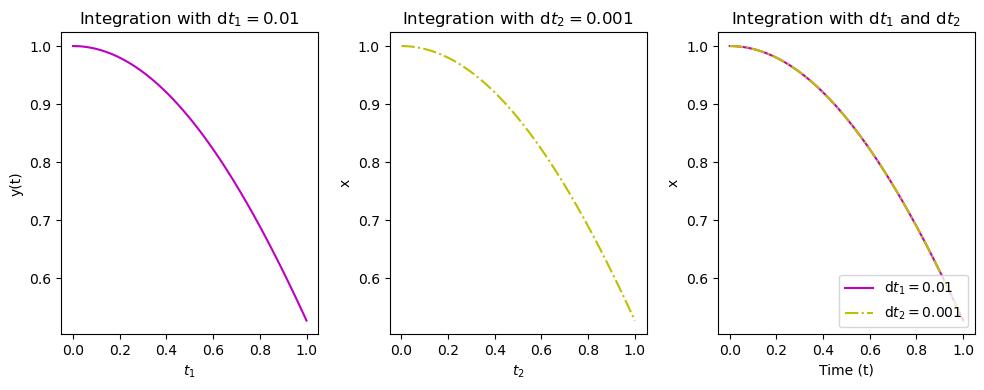

In [3]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10,4))
ax1.plot(t1, Y1[0],'-', color = 'm')
ax1.set_xlabel("$t_1$")
ax1.set_ylabel("y(t)")
ax1.set_title("Integration with d$t_1=0.01$")

ax2.plot(t2, Y2[0], '-.', color= 'y')
ax2.set_xlabel("$t_2$")
ax2.set_ylabel("x")
ax2.set_title("Integration with d$t_2=0.001$")

ax3.plot(t1, Y1[0],'-', color = 'm', label="d$t_1 = 0.01$")
ax3.plot(t2, Y2[0], '-.', color= 'y', label= "d$t_2 = 0.001$")

ax3.set_xlabel("Time (t)")
ax3.set_ylabel("x")
ax3.set_title("Integration with d$t_1$ and d$t_2$")
ax3.legend(loc = "lower right")

plt.tight_layout()
plt.show()